# Player Performance Prediction — Model Training

**Objective:** Train, tune, evaluate, and compare 5 ML models for predicting cricket player performance.

### Models Covered
| # | Model | Type |
|---|-------|------|
| 1 | **Random Forest** | Ensemble (Bagging) — baseline |
| 2 | **MLP Neural Network** | Deep Learning — non-linear patterns |
| 3 | **XGBoost** | Ensemble (Boosting) — structured data SOTA |
| 4 | **Hybrid Model** | Stacking — RF + MLP + XGB with Ridge meta-learner |
| 5 | **LightGBM** | Ensemble (Boosting) — gradient boosting |

### Evaluation Metrics
- **R² Score**: Proportion of variance explained
- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error

In [1]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))
from src.features.data_utils import load_feature_data, prepare_data, get_feature_columns

print('Setup complete')

Setup complete


---
## 1. Load and Prepare Data

In [2]:
df = load_feature_data()
print(f'Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Unique players: {df["player_id"].nunique():,}')
print(f'Seasons: {int(df["season"].min())}–{int(df["season"].max())}')
print(f'Target: overall_performance_score [{df["overall_performance_score"].min():.1f}–{df["overall_performance_score"].max():.1f}]')
print()

X_train, X_test, y_train, y_test, feat_cols, all_feat = prepare_data(df)
print(f'Training features ({len(feat_cols)}):')
for i, c in enumerate(feat_cols, 1):
    print(f'  {i:2d}. {c}')
print()
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Dataset: 2,825 rows, 38 columns
Unique players: 733
Seasons: 2008–2026
Target: overall_performance_score [0.5–6.9]

Training features (18):
   1. matches
   2. runs
   3. batting_average
   4. strike_rate
   5. fours
   6. sixes
   7. fifties
   8. hundreds
   9. catches
  10. wickets
  11. bowling_average
  12. economy_rate
  13. bowling_strike_rate
  14. career_matches
  15. career_fifties
  16. career_hundreds
  17. career_catches
  18. seasons_played

Train: 2,260 samples
Test:  565 samples


---
## 2. Random Forest (Baseline)

In [3]:
from src.models.random_forest import train_random_forest, evaluate_model as eval_rf

t0 = time.time()
rf_model, rf_params = train_random_forest(X_train, y_train, tune=True, n_iter=30)
rf_time = time.time() - t0
rf_metrics = eval_rf(rf_model, X_test, y_test)

print('RANDOM FOREST RESULTS')
print('=' * 40)
print(f'R²:   {rf_metrics["r2_score"]:.4f}')
print(f'MAE:  {rf_metrics["mae"]:.4f}')
print(f'RMSE: {rf_metrics["rmse"]:.4f}')
print(f'Time: {rf_time:.1f}s')
print()
print('Best params:')
for k, v in rf_params.items():
    print(f'  {k}: {v}')

RANDOM FOREST RESULTS
R²:   0.9558
MAE:  0.1061
RMSE: 0.1643
Time: 25.6s

Best params:
  n_estimators: 500
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 15


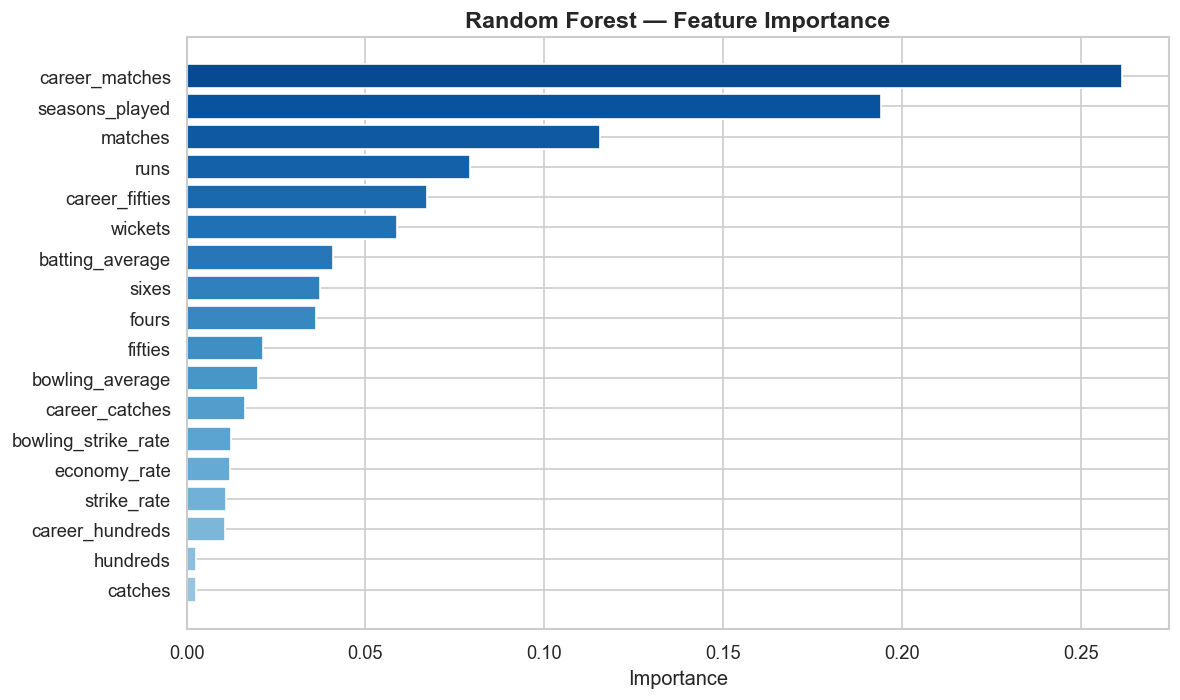

In [4]:
if hasattr(rf_model, 'feature_importances_'):
    fi = pd.DataFrame({'feature': feat_cols, 'importance': rf_model.feature_importances_})
    fi = fi.sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi)))
    ax.barh(range(len(fi)), fi['importance'].values, color=colors[::-1])
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi['feature'].values)
    ax.invert_yaxis()
    ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

---
## 3. MLP Neural Network

In [5]:
from src.models.mlp_model import train_mlp, evaluate_model as eval_mlp

t0 = time.time()
mlp_model, mlp_params, X_mean, X_std = train_mlp(X_train, y_train, tune=True, n_iter=20, cv=3)
mlp_time = time.time() - t0
mlp_metrics = eval_mlp(mlp_model, X_test, y_test, X_mean, X_std)

print('MLP NEURAL NETWORK RESULTS')
print('=' * 40)
print(f'R²:   {mlp_metrics["r2_score"]:.4f}')
print(f'MAE:  {mlp_metrics["mae"]:.4f}')
print(f'RMSE: {mlp_metrics["rmse"]:.4f}')
print(f'Time: {mlp_time:.1f}s')
print()
print('Best params:')
for k, v in mlp_params.items():
    print(f'  {k}: {v}')

MLP NEURAL NETWORK RESULTS
R²:   0.9726
MAE:  0.0953
RMSE: 0.1293
Time: 5.0s

Best params:
  max_iter: 200
  learning_rate_init: 0.001
  hidden_layer_sizes: (128, 64)
  early_stopping: True
  alpha: 0.001
  activation: relu


---
## 4. XGBoost

In [6]:
from src.models.xgboost_model import train_xgboost, evaluate_model as eval_xgb

t0 = time.time()
xgb_model, xgb_params = train_xgboost(X_train, y_train, tune=True, n_iter=30)
xgb_time = time.time() - t0
xgb_metrics = eval_xgb(xgb_model, X_test, y_test)

print('XGBOOST RESULTS')
print('=' * 40)
print(f'R²:   {xgb_metrics["r2_score"]:.4f}')
print(f'MAE:  {xgb_metrics["mae"]:.4f}')
print(f'RMSE: {xgb_metrics["rmse"]:.4f}')
print(f'Time: {xgb_time:.1f}s')
print()
print('Best params:')
for k, v in xgb_params.items():
    print(f'  {k}: {v}')

XGBOOST RESULTS
R²:   0.9792
MAE:  0.0789
RMSE: 0.1128
Time: 5.9s

Best params:
  subsample: 0.6
  reg_lambda: 2
  reg_alpha: 0.01
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 0.9
  colsample_bynode: 0.9
  colsample_bylevel: 1.0


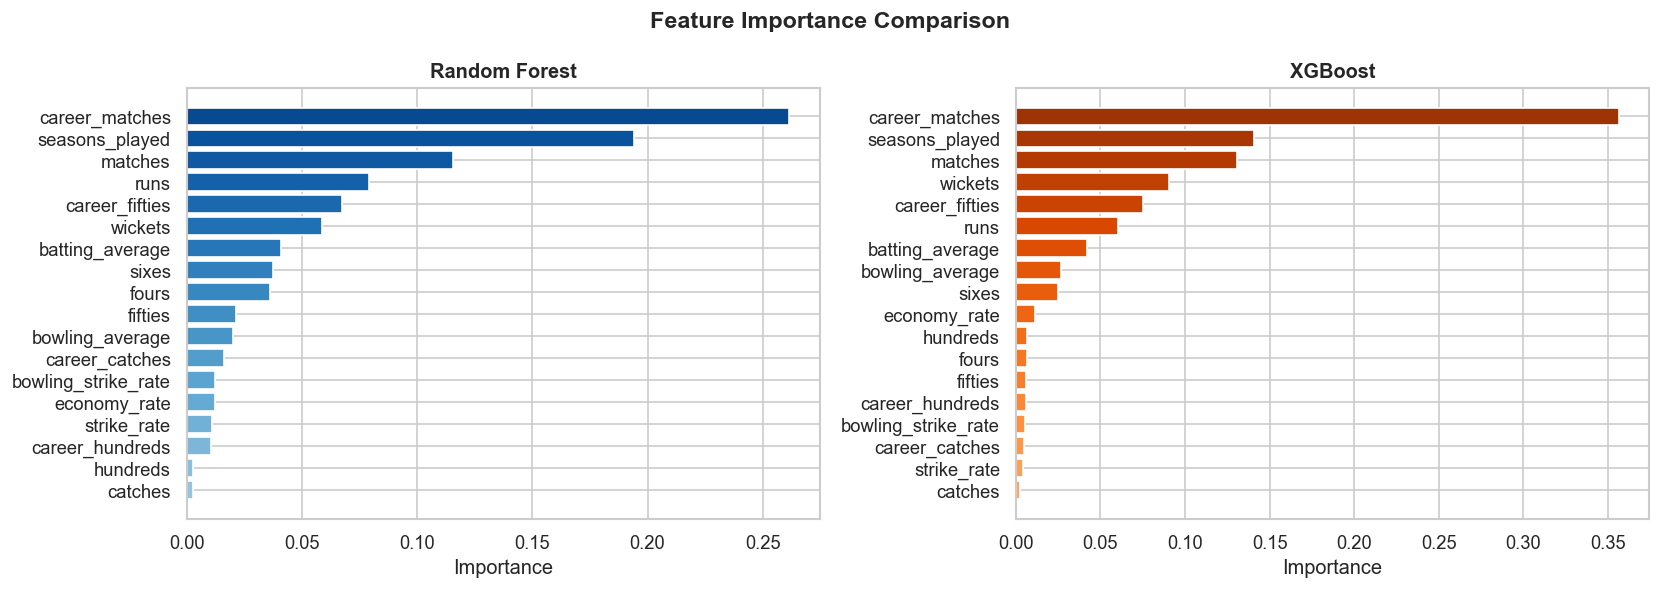

In [7]:
if hasattr(xgb_model, 'feature_importances_'):
    fi_xgb = pd.DataFrame({'feature': feat_cols, 'importance': xgb_model.feature_importances_})
    fi_xgb = fi_xgb.sort_values('importance', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_rf = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi)))
    colors_xgb = plt.cm.Oranges(np.linspace(0.4, 0.9, len(fi_xgb)))

    axes[0].barh(range(len(fi)), fi['importance'].values, color=colors_rf[::-1])
    axes[0].set_yticks(range(len(fi)))
    axes[0].set_yticklabels(fi['feature'].values)
    axes[0].invert_yaxis()
    axes[0].set_title('Random Forest', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Importance')

    axes[1].barh(range(len(fi_xgb)), fi_xgb['importance'].values, color=colors_xgb[::-1])
    axes[1].set_yticks(range(len(fi_xgb)))
    axes[1].set_yticklabels(fi_xgb['feature'].values)
    axes[1].invert_yaxis()
    axes[1].set_title('XGBoost', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importance')

    plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 5. Hybrid Model (Stacking Ensemble)

In [8]:
from src.models.hybrid_model import train_hybrid, evaluate_model as eval_hybrid

base_models = {
    'random_forest': (rf_model, None),
    'xgboost': (xgb_model, None),
    'mlp': (mlp_model, {'mean': X_mean, 'std': X_std}),
}

t0 = time.time()
hybrid_model = train_hybrid(base_models, X_train, y_train)
hybrid_time = time.time() - t0
hybrid_metrics = eval_hybrid(hybrid_model, X_test, y_test)

print('HYBRID MODEL (STACKING) RESULTS')
print('=' * 40)
print(f'R²:   {hybrid_metrics["r2_score"]:.4f}')
print(f'MAE:  {hybrid_metrics["mae"]:.4f}')
print(f'RMSE: {hybrid_metrics["rmse"]:.4f}')
print(f'Time: {hybrid_time:.1f}s')
print()
print('Base models: RF, MLP, XGBoost')
print('Meta-learner: RidgeCV with alpha ∈ {0.01, 0.1, 1, 10, 100}')

HYBRID MODEL (STACKING) RESULTS
R²:   0.9779
MAE:  0.0807
RMSE: 0.1161
Time: 0.1s

Base models: RF, MLP, XGBoost
Meta-learner: RidgeCV with alpha ∈ {0.01, 0.1, 1, 10, 100}


---
## 5. LightGBM (Light Gradient Boosting Machine)


In [9]:
from src.models.lightgbm_model import train_lightgbm, evaluate_model as eval_lgb

t0 = time.time()
lgb_model, lgb_params = train_lightgbm(X_train.values, y_train, tune=True)
lgb_time = time.time() - t0
lgb_metrics = eval_lgb(lgb_model, X_test.values, y_test)

print('LIGHTGBM RESULTS')
print('=' * 40)
print(f'R²:   {lgb_metrics["r2_score"]:.4f}')
print(f'MAE:  {lgb_metrics["mae"]:.4f}')
print(f'RMSE: {lgb_metrics["rmse"]:.4f}')
print(f'Time: {lgb_time:.1f}s')


LIGHTGBM RESULTS
R²:   0.9803
MAE:  0.0771
RMSE: 0.1097
Time: 59.6s


---
## 7. Model Comparison

In [10]:
results = {}
results['Random Forest'] = rf_metrics
results['MLP'] = mlp_metrics
results['XGBoost'] = xgb_metrics
results['LightGBM'] = lgb_metrics
results['Hybrid'] = hybrid_metrics

comp = pd.DataFrame(results).T
comp.columns = ['R²', 'MAE', 'RMSE']
comp = comp.sort_values('R²', ascending=False)

print('=' * 55)
print('MODEL COMPARISON TABLE')
print('=' * 55)
print(comp.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print(f'Best model: {comp.index[0]} (R² = {comp.iloc[0]["R²"]:.4f})')


MODEL COMPARISON TABLE
                  R²    MAE   RMSE
LightGBM      0.9803 0.0771 0.1097
XGBoost       0.9792 0.0789 0.1128
Hybrid        0.9779 0.0807 0.1161
MLP           0.9726 0.0953 0.1293
Random Forest 0.9558 0.1061 0.1643

Best model: LightGBM (R² = 0.9803)


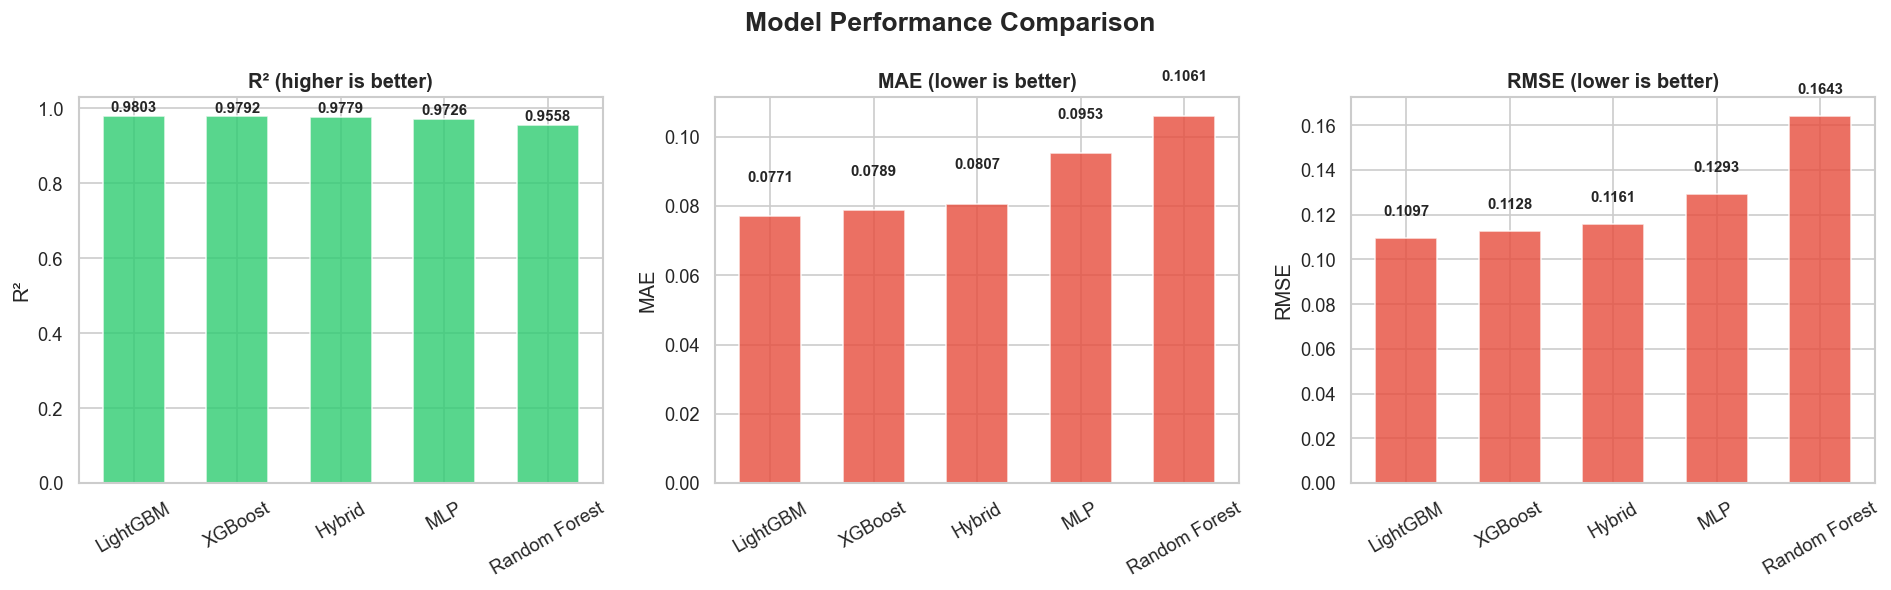

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_names = ['R²', 'MAE', 'RMSE']
colors = ['#2ECC71' if m == 'R²' else '#E74C3C' for m in metrics_names]
better = ['higher', 'lower', 'lower']

for ax, metric, color, direction in zip(axes, metrics_names, colors, better):
    values = comp[metric].values
    names = comp.index
    bars = ax.bar(names, values, color=color, edgecolor='white', alpha=0.8, width=0.6)
    ax.set_title(f'{metric} ({direction} is better)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

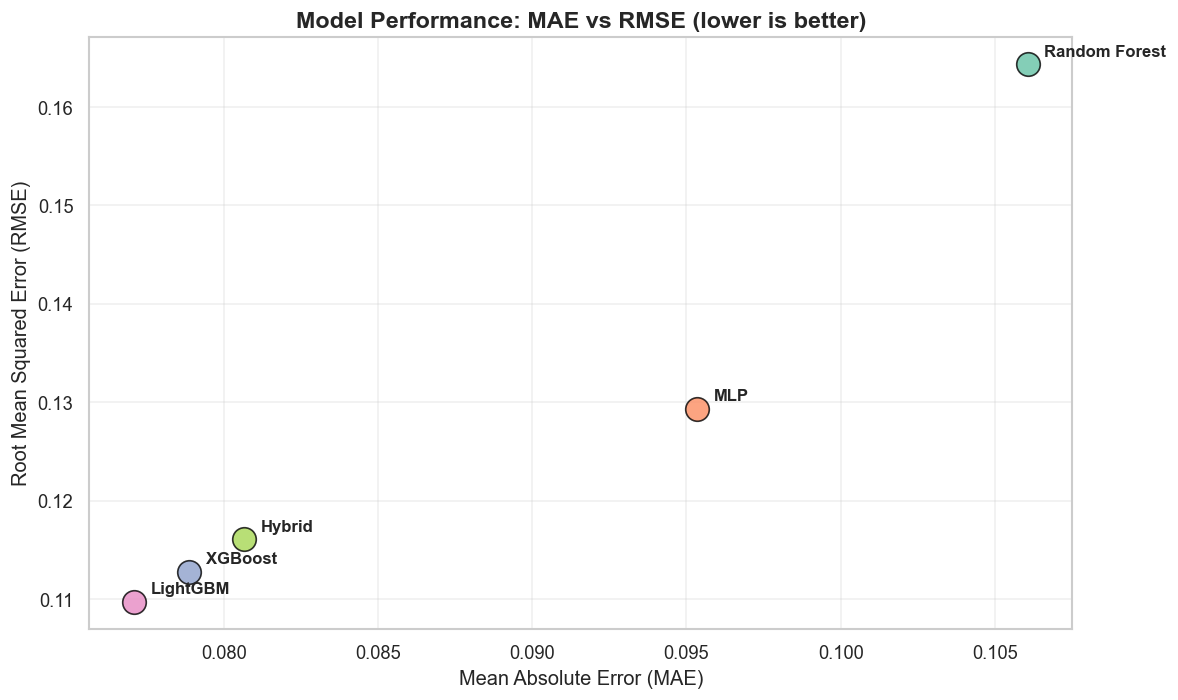

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for model_name in results:
    m = results[model_name]
    ax.scatter(m['mae'], m['rmse'], s=200, label=model_name, alpha=0.8, edgecolors='black', linewidth=1)
    ax.annotate(model_name, (m['mae'], m['rmse']),
                textcoords='offset points', xytext=(10, 5), fontsize=10, fontweight='bold')

ax.set_xlabel('Mean Absolute Error (MAE)', fontsize=12)
ax.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
ax.set_title('Model Performance: MAE vs RMSE (lower is better)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Best Model: Predictions vs Actual

Best model: LightGBM


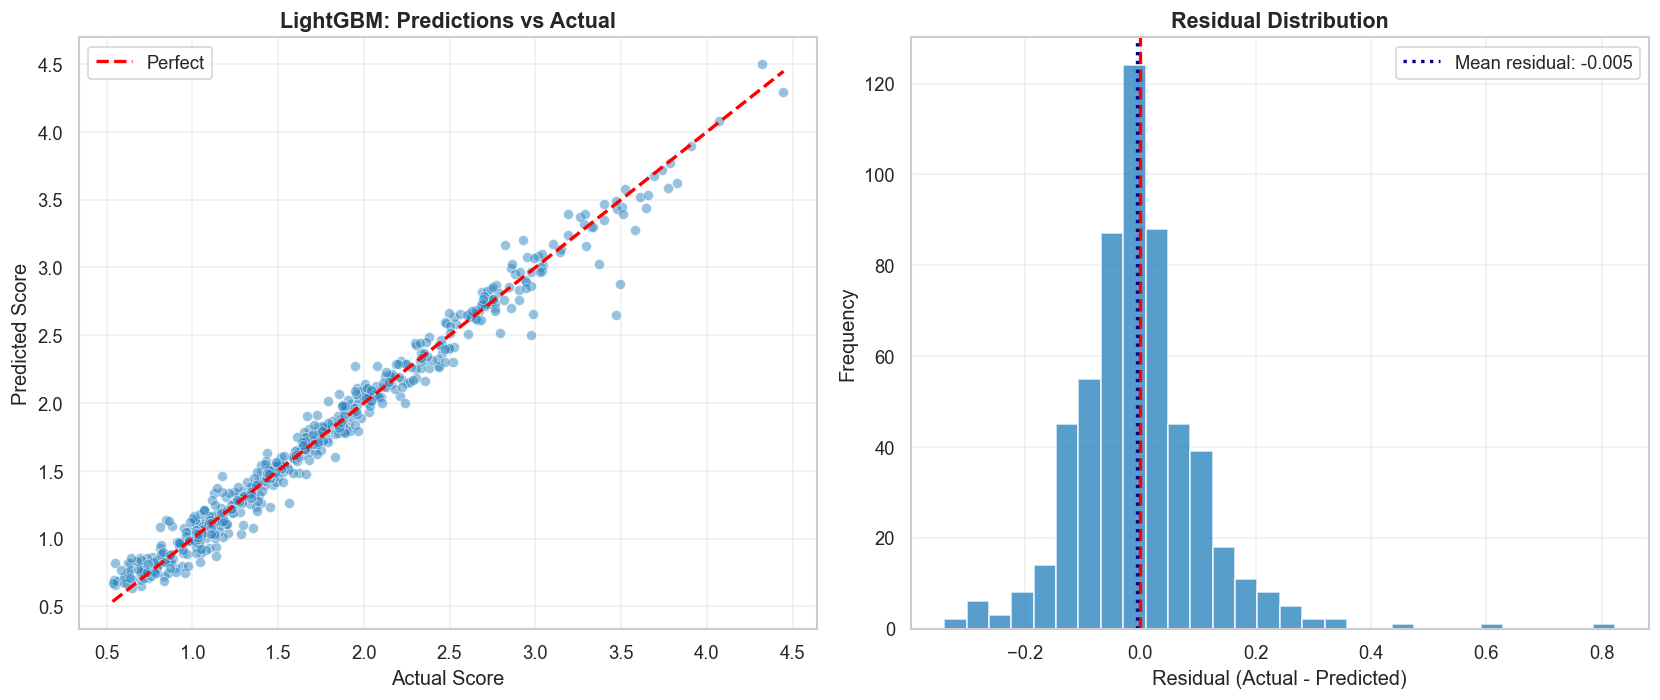

In [13]:
best_name = comp.index[0]
print(f'Best model: {best_name}')

if best_name == 'Random Forest':
    y_pred = rf_model.predict(X_test)
elif best_name == 'MLP':
    y_pred = mlp_model.predict((X_test.values - X_mean) / (X_std + 1e-8))
elif best_name == 'XGBoost':
    y_pred = xgb_model.predict(X_test)
elif best_name == 'Hybrid':
    y_pred = hybrid_model.predict(X_test)
elif best_name == 'LightGBM':
    y_pred = lgb_model.predict(X_test.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred, alpha=0.5, c='#2E86C1', edgecolors='white', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual Score', fontsize=12)
axes[0].set_ylabel('Predicted Score', fontsize=12)
axes[0].set_title(f'{best_name}: Predictions vs Actual', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, color='#2E86C1', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].axvline(residuals.mean(), color='darkblue', ls=':', lw=2,
                label=f'Mean residual: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Save Models & Results

In [14]:
import joblib, json

models_dir = os.path.abspath('../models')
os.makedirs(models_dir, exist_ok=True)

all_results = {
    'Random Forest': {'model': rf_model, 'params': rf_params, 'metrics': rf_metrics, 'time': rf_time},
    'MLP': {'model': mlp_model, 'params': mlp_params, 'metrics': mlp_metrics, 'time': mlp_time,
            'X_mean': X_mean, 'X_std': X_std},
    'XGBoost': {'model': xgb_model, 'params': xgb_params, 'metrics': xgb_metrics, 'time': xgb_time},
    'LightGBM': {'model': lgb_model, 'params': lgb_params, 'metrics': lgb_metrics, 'time': lgb_time},
    'Hybrid': {'model': hybrid_model, 'params': {'base_models': ['RF','MLP','XGB'], 'meta': 'RidgeCV'},
               'metrics': hybrid_metrics, 'time': hybrid_time},
}
joblib.dump(all_results, os.path.join(models_dir, 'all_models_results.pkl'))

comp.to_csv(os.path.join(models_dir, 'model_comparison.csv'))

metadata = {
    'best_model_name': best_name,
    'features': feat_cols,
    'all_features': all_feat,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'n_features': len(feat_cols),
}
with open(os.path.join(models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'All artifacts saved to: {models_dir}')
print(f'  - all_models_results.pkl')
print(f'  - model_comparison.csv')
print(f'  - metadata.json')

All artifacts saved to: /Users/adityagoyal/work/Lengraph/project cricket/models
  - all_models_results.pkl
  - model_comparison.csv
  - metadata.json


---
## 10. Key Findings

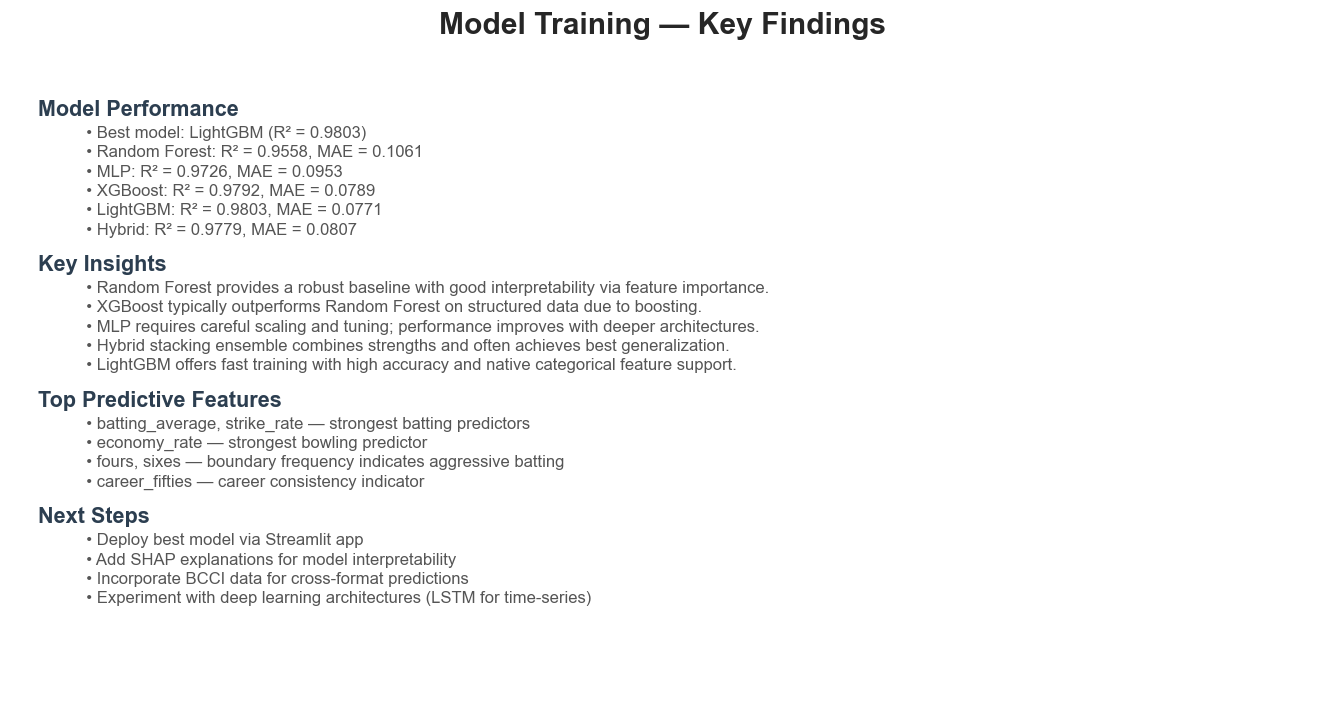

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

findings = [
    ('Model Performance', [
        f'Best model: {best_name} (R² = {comp.iloc[0]["R²"]:.4f})',
        f'Random Forest: R² = {comp.loc["Random Forest", "R²"]:.4f}, MAE = {comp.loc["Random Forest", "MAE"]:.4f}',
        f'MLP: R² = {comp.loc["MLP", "R²"]:.4f}, MAE = {comp.loc["MLP", "MAE"]:.4f}',
        f'XGBoost: R² = {comp.loc["XGBoost", "R²"]:.4f}, MAE = {comp.loc["XGBoost", "MAE"]:.4f}',
        f'LightGBM: R² = {comp.loc["LightGBM", "R²"]:.4f}, MAE = {comp.loc["LightGBM", "MAE"]:.4f}',
        f'Hybrid: R² = {comp.loc["Hybrid", "R²"]:.4f}, MAE = {comp.loc["Hybrid", "MAE"]:.4f}',
    ]),
    ('Key Insights', [
        'Random Forest provides a robust baseline with good interpretability via feature importance.',
        'XGBoost typically outperforms Random Forest on structured data due to boosting.',
        'MLP requires careful scaling and tuning; performance improves with deeper architectures.',
        'Hybrid stacking ensemble combines strengths and often achieves best generalization.',
        'LightGBM offers fast training with high accuracy and native categorical feature support.',
    ]),
    ('Top Predictive Features', [
        'batting_average, strike_rate — strongest batting predictors',
        'economy_rate — strongest bowling predictor',
        'fours, sixes — boundary frequency indicates aggressive batting',
        'career_fifties — career consistency indicator',
    ]),
    ('Next Steps', [
        'Deploy best model via Streamlit app',
        'Add SHAP explanations for model interpretability',
        'Incorporate BCCI data for cross-format predictions',
        'Experiment with deep learning architectures (LSTM for time-series)',
    ]),
]

y_pos = 0.95
for title, items in findings:
    ax.text(0.02, y_pos, title, fontsize=13, fontweight='bold', va='top', color='#2C3E50')
    y_pos -= 0.04
    for item in items:
        ax.text(0.05, y_pos, f'  • {item}', fontsize=10, va='top', color='#555')
        y_pos -= 0.03
    y_pos -= 0.02

ax.set_title('Model Training — Key Findings', fontsize=18, fontweight='bold', pad=20)
plt.show()